##  PCA with all_data and all_data_normalized

#### vorher installieren:
- scikit-learn
---
#### Ziel von PCA:
- Anzahl an Variablen reduzieren, um die Daten übersichtlicher zu machen
- Muster, Gruppen oder Ausreißer in den Daten sichtbar machen
- Korrelationen zwischen Variablen auflösen
- Daten komprimieren, ohne viel Information zu verlieren
---
#### Wie funktioniert PCA?
 - Standardisierung der Daten
    - Alle numerischen Variablen werden auf die gleiche Skala gebracht
    (wichtig, weil PCA auf Distanzen und Varianz basiert und sonst stark verzerrt wäre)

- Berechnung der Kovarianzmatrix
    - Zeigt, wie stark die Variablen miteinander zusammenhängen

- Berechnung der Hauptkomponenten (Principal Components = PC)
     = neue Achsen im Merkmalsraum

- Projektion der Daten auf die neuen Achsen
    - ursprünglichen Daten werden in das neue Koordinatensystem überführt (transformiert)

- Visualisierung in Sd Plot
---


##  PCA with all_data_normalized

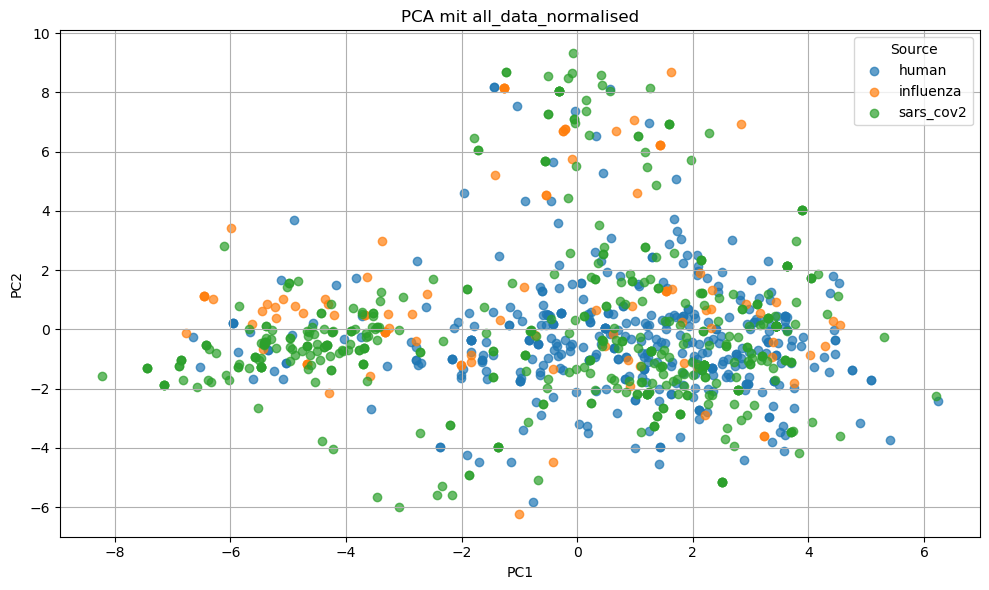

Variance explained by PC1: 6.51%
Variance explained by PC2: 4.70%


In [10]:
import pandas as pd  # Bibliothek zum Arbeiten mit Tabellen (DataFrames)
import matplotlib.pyplot as plt  # Bibliothek zum Plotten von Diagrammen
from sklearn.decomposition import PCA  # PCA-Modul aus scikit-learn
from sklearn.preprocessing import StandardScaler  # Standardisierung von Daten

# Schritt 1: Datensatz laden
df = pd.read_csv("../../generated/cdrs/seq/all_data_normalized.tsv", sep="\t")  # Lese TSV-Datei ein
df  # Zeigt den DataFrame (zur Kontrolle, hat keine weitere Funktion)

# Schritt 2: Auswahl aller numerischen Spalten (nicht-string-Spalten)
exclude_cols = ['pdb', 'heavy_chain', 'CDR_H1', 'CDR_H2', 'CDR_H3', 'source']  # Diese Spalten sollen ausgeschlossen werden
numeric_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]  
# Liste aller numerischen Spalten, außer denen aus exclude_cols

# Schritt 3: Extrahiere die Merkmalsmatrix (Feature-Matrix)
X = df[numeric_cols].copy()  # Kopiere nur die numerischen Spalten (unsere Input-Daten für PCA)

# Fehlende Werte (NaNs) durch den Mittelwert der Spalte ersetzen
X_imputed = X.fillna(X.mean())  # ersetzt NaN-Werte durch den Spaltenmittelwert

# Schritt 4: Standardisierung der Daten
scaler = StandardScaler()  # Erstellt ein StandardScaler-Objekt
X_scaled = scaler.fit_transform(X_imputed)  # Skaliert alle Spalten auf Mittelwert=0, Standardabweichung=1

# Schritt 5: Durchführung der PCA (nur 2 Hauptkomponenten)
pca = PCA(n_components=2)  # PCA-Objekt erstellen, das 2 Hauptkomponenten berechnet
X_pca = pca.fit_transform(X_scaled)  # Führe PCA durch → transformiere auf neuen Koordinaten (PC1, PC2)

# Schritt 6: Erstelle neuen DataFrame mit PCA-Ergebnissen
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])  # Speichere PC1 und PC2 in einem neuen DataFrame
pca_df["source"] = df["source"]  # Füge die Gruppenzugehörigkeit (z. B. human/influenza/sars) hinzu

# Schritt 7: Zeichne das PCA-Ergebnis
plt.figure(figsize=(10, 6))  # Erzeuge eine neue Plotfläche (10x6 Zoll)
for group in pca_df["source"].unique():  # Schleife über alle Gruppen (z. B. "human", "influenza", ...)
    subset = pca_df[pca_df["source"] == group]  # Wähle alle Punkte aus dieser Gruppe
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)  # Zeichne die Punkte dieser Gruppe

plt.xlabel("PC1")  # Achsenbeschriftung x
plt.ylabel("PC2")  # Achsenbeschriftung y
plt.title("PCA mit all_data_normalised")  # Titel des Diagramms
plt.legend(title="Source")  # Legende mit Titel „Source“
plt.grid(True)  # Gitterlinien anzeigen
plt.tight_layout()  # Verhindert abgeschnittene Elemente im Plot
plt.show()  # Zeigt den fertigen Plot

# Schritt 8: Drucke die erklärte Varianz
explained = pca.explained_variance_ratio_  # Anteil der erklärten Varianz jeder Komponente
print(f"Variance explained by PC1: {explained[0]:.2%}")  # Anteil Varianz durch PC1 in Prozent
print(f"Variance explained by PC2: {explained[1]:.2%}")  # Anteil Varianz durch PC2 in Prozent


### Interpretation PCA all_data_normalized:
- PC1 und PC2 erklären 11,21% der Gesamtvarianz
= das bedeutet unsere Daten sind sehr Komplex und können nicht gut mit zwei Achsen beschrieben werden
- es können keine eindeutigen Muster oder Gruppen bestimmt werden :(
---
##  PCA with all_data 

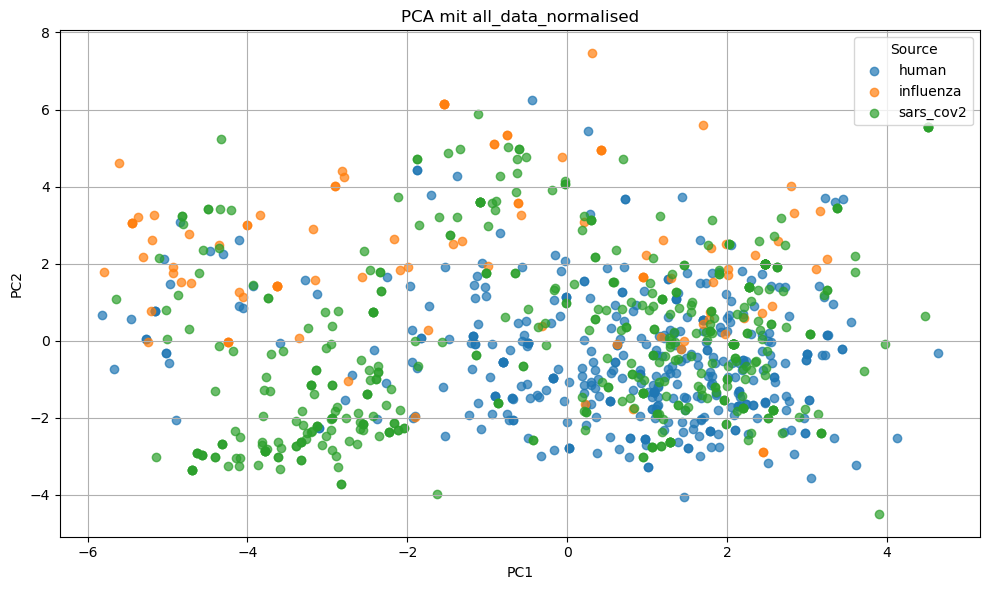

Variance explained by PC1: 7.38%
Variance explained by PC2: 5.62%


In [11]:
# Schritt 1: Datensatz laden
df = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")  # Lese TSV-Datei ein
df  # Zeigt den DataFrame (zur Kontrolle, hat keine weitere Funktion)

# Schritt 2: Auswahl aller numerischen Spalten (nicht-string-Spalten)
exclude_cols = ['pdb', 'heavy_chain', 'CDR_H1', 'CDR_H2', 'CDR_H3', 'source']  # Diese Spalten sollen ausgeschlossen werden
numeric_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]  
# Liste aller numerischen Spalten, außer denen aus exclude_cols

# Schritt 3: Extrahiere die Merkmalsmatrix (Feature-Matrix)
X = df[numeric_cols].copy()  # Kopiere nur die numerischen Spalten (unsere Input-Daten für PCA)

# Fehlende Werte (NaNs) durch den Mittelwert der Spalte ersetzen
X_imputed = X.fillna(X.mean())  # ersetzt NaN-Werte durch den Spaltenmittelwert

# Schritt 4: Standardisierung der Daten
scaler = StandardScaler()  # Erstellt ein StandardScaler-Objekt
X_scaled = scaler.fit_transform(X_imputed)  # Skaliert alle Spalten auf Mittelwert=0, Standardabweichung=1

# Schritt 5: Durchführung der PCA (nur 2 Hauptkomponenten)
pca = PCA(n_components=2)  # PCA-Objekt erstellen, das 2 Hauptkomponenten berechnet
X_pca = pca.fit_transform(X_scaled)  # Führe PCA durch → transformiere auf neuen Koordinaten (PC1, PC2)

# Schritt 6: Erstelle neuen DataFrame mit PCA-Ergebnissen
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])  # Speichere PC1 und PC2 in einem neuen DataFrame
pca_df["source"] = df["source"]  # Füge die Gruppenzugehörigkeit (z. B. human/influenza/sars) hinzu

# Schritt 7: Zeichne das PCA-Ergebnis
plt.figure(figsize=(10, 6))  # Erzeuge eine neue Plotfläche (10x6 Zoll)
for group in pca_df["source"].unique():  # Schleife über alle Gruppen (z. B. "human", "influenza", ...)
    subset = pca_df[pca_df["source"] == group]  # Wähle alle Punkte aus dieser Gruppe
    plt.scatter(subset["PC1"], subset["PC2"], label=group, alpha=0.7)  # Zeichne die Punkte dieser Gruppe

plt.xlabel("PC1")  # Achsenbeschriftung x
plt.ylabel("PC2")  # Achsenbeschriftung y
plt.title("PCA mit all_data_normalised")  # Titel des Diagramms
plt.legend(title="Source")  # Legende mit Titel „Source“
plt.grid(True)  # Gitterlinien anzeigen
plt.tight_layout()  # Verhindert abgeschnittene Elemente im Plot
plt.show()  # Zeigt den fertigen Plot

# Schritt 8: Drucke die erklärte Varianz
explained = pca.explained_variance_ratio_  # Anteil der erklärten Varianz jeder Komponente
print(f"Variance explained by PC1: {explained[0]:.2%}")  # Anteil Varianz durch PC1 in Prozent
print(f"Variance explained by PC2: {explained[1]:.2%}")  # Anteil Varianz durch PC2 in Prozent


### Interpretation PCA all_data:
- PC1 und PC2 erklären 13% der Gesamtvarianz
= das bedeutet unsere Daten sind sehr Komplex und können nicht gut mit zwei Achsen beschrieben werden
-(auch hier) es können keine eindeutigen Muster oder Gruppen bestimmt werden :(
---
